# Test the YOLO + CNN two-stage column detector on a real floor plan

1. Tile the plan into 1280-px windows (matches the synthetic training geometry).
2. Run the **frozen** YOLO detector (`column_detect.pt`) on every tile, merge across overlaps.
3. Post-process: aspect / size / shape / OCR / centre-NMS / IoU-NMS (`scripts/postprocess_pipeline.py`).
4. **Two-stage classifier filter** — `column_review/bbox_classifier.py` re-scores each surviving bbox crop (64×64) and drops anything below `CLASSIFIER_THRESHOLD`. Trained via `python3 scripts/train_bbox_classifier.py`.
5. Annotate + render to `output/<plan>_columns.png`.

Tune `CLASSIFIER_THRESHOLD` in cell 2 and re-run cells 5+5b to see the impact without re-running YOLO. Missing classifier weights → cell 5b passes through and notes the skip; the rest of the notebook still works.

In [1]:
from pathlib import Path
import numpy as np
import torch
import torchvision.ops as tvops
from PIL import Image, ImageDraw, ImageFont
from ultralytics import YOLO
import matplotlib.pyplot as plt

Image.MAX_IMAGE_PIXELS = None  # large floor plans exceed Pillow's default cap


In [3]:
# ── CONFIG ──────────────────────────────────────────────────────────────
# Detector weights (frozen baseline). NEVER point this at a bad fine-tune
# without a separate inspection cell — the cascade preserves YOLO's
# distribution by design.
DETECT_WEIGHTS = Path('column_detect.pt')

# CNN classifier weights — trained by `python3 scripts/train_bbox_classifier.py`.
# Resolved against the project root in cell 3 so the notebook works from
# any cwd. Set USE_CLASSIFIER=False to disable the second stage entirely
# (YOLO-only mode, same as the pre-cascade behavior).
CLASSIFIER_WEIGHTS   = Path('column_classifier.pt')
CLASSIFIER_THRESHOLD = 0.5     # tune in cell 5b without re-running YOLO
USE_CLASSIFIER       = True

#IMAGE_PATH = Path('/home/jiezhi/Documents/TGCH floor plan/L3.jpg')
IMAGE_PATH = Path('/home/jiezhi/Documents/1-column-train/T5-tender.jpg')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

TILE_SIZE  = 1280
TILE_STEP  = 1080            # 200 px overlap, same as training
CONF_TH    = 0.25            # detection confidence threshold
IOU_TH     = 0.45            # NMS IoU threshold (across tiles)
DEVICE     = 0 if torch.cuda.is_available() else 'cpu'

print(f'detector   : {DETECT_WEIGHTS}')
print(f'classifier : {CLASSIFIER_WEIGHTS} (use={USE_CLASSIFIER}, thresh={CLASSIFIER_THRESHOLD})')
print(f'image      : {IMAGE_PATH}')
print(f'device     : {DEVICE}')


detector   : column_detect.pt
classifier : column_classifier.pt (use=True, thresh=0.5)
image      : /home/jiezhi/Documents/1-column-train/T5-tender.jpg
device     : 0


In [4]:
# ── LOAD MODEL + IMAGE ───────────────────────────────────────────────────
# Walk up to find scripts/ so the notebook works regardless of cwd.
import sys
from pathlib import Path as _Path
_search = [_Path.cwd(), *_Path.cwd().parents]
ROOT = next(
    (p for p in _search if (p / 'scripts' / 'tiled_inference.py').exists()),
    None,
)
if ROOT is None:
    raise FileNotFoundError(
        f'Could not locate scripts/tiled_inference.py walking up from {_Path.cwd()}'
    )
if str(ROOT / 'scripts') not in sys.path:
    sys.path.insert(0, str(ROOT / 'scripts'))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))   # for `column_review.bbox_classifier`

# Resolve weight paths against ROOT so relative `Path('column_detect.pt')`
# in the CONFIG cell still works when the notebook is opened from a
# subdirectory.
if not DETECT_WEIGHTS.is_absolute():
    DETECT_WEIGHTS = ROOT / DETECT_WEIGHTS
if not CLASSIFIER_WEIGHTS.is_absolute():
    CLASSIFIER_WEIGHTS = ROOT / CLASSIFIER_WEIGHTS

detector = YOLO(str(DETECT_WEIGHTS))
img      = Image.open(IMAGE_PATH).convert('RGB')
W, H     = img.size
print(f'image size: {W} × {H} px')
print(f'classifier available: {CLASSIFIER_WEIGHTS.is_file()} ({CLASSIFIER_WEIGHTS})')


image size: 14044 × 9934 px
classifier available: True (/home/jiezhi/Documents/1-column-train/column_classifier.pt)


In [6]:
# ── TILED INFERENCE via shared helper ────────────────────────────────────
# `scripts/tiled_inference.tiled_predict` is the single source of truth
# for tile geometry, white-padding, and per-tile detection-count tracking.
# `column_review/inference.py` (the production path) calls the same helper.
from tiled_inference import tiled_predict, n_tiles_for_image

INPUT_DPI = 300   # second public knob — must match the rasterisation DPI

all_boxes, all_scores, tile_counts = tiled_predict(
    detector, img,
    tile=TILE_SIZE, step=TILE_STEP,
    conf=CONF_TH, iou=IOU_TH,
    device=DEVICE,
)
n_grid = n_tiles_for_image(W, H, tile=TILE_SIZE, step=TILE_STEP)
print(f'tiles processed: {len(tile_counts)}  (grid: {n_grid})')
print(f'raw detections (pre-NMS): {len(all_boxes)}')
if tile_counts:
    print(f'per-tile dets: min={min(tile_counts)} max={max(tile_counts)} '
          f'mean={sum(tile_counts)/len(tile_counts):.2f}')


tiles processed: 130  (grid: 130)
raw detections (pre-NMS): 224
per-tile dets: min=0 max=28 mean=1.72


In [7]:
# ── POST-PROCESSING via shared module ───────────────────────────────────
# Runs `run_pipeline` WITHOUT the classifier stage so cell 5b can plot a
# P(column) histogram across all post-NMS survivors. Production parity
# (classifier inside the pipeline, before centre-NMS) lives in
# `column_review/inference.py` — the split here is only for threshold
# tuning visibility, not a behavioural divergence.
from postprocess_pipeline import run_pipeline, DEFAULT_CONFIG, format_audit
from ood_detector import OutOfDistributionError

img_gray = np.asarray(img.convert('L'))

try:
    boxes_pre_classifier, scores_pre_classifier, audit = run_pipeline(
        img_gray, all_boxes, all_scores,
        config=DEFAULT_CONFIG,           # classifier OFF — applied in cell 5b
        input_dpi=INPUT_DPI,
        tile_detection_counts=tile_counts,
    )
except OutOfDistributionError as e:
    print(f'OOD HARD FAILURE: {e}')
    print('Refusing to emit predictions. Fix the rasterisation and re-run.')
    raise

print(format_audit(audit))
print()
print(f'post-process survivors                : {len(boxes_pre_classifier)}')


raw                   : 224
after aspect          : 215
after size            : 212
after shape           : 165
after OCR text        : 143
after centre-NMS      : 95
FINAL                 : 95

post-process survivors                : 95


[classifier] loading column_classifier.pt on cuda:0…


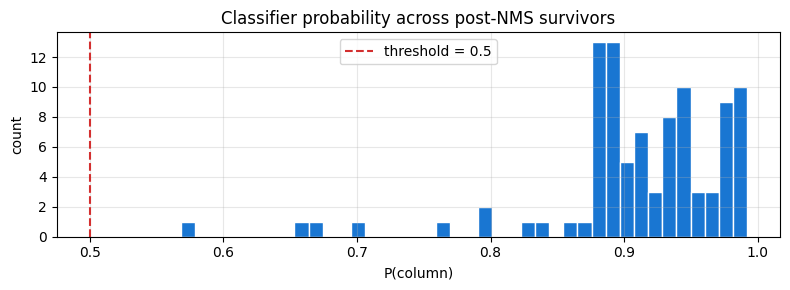

kept 95 of 95 (rejected 0 below threshold 0.5)


In [8]:
# ── CLASSIFIER SCORING + HISTOGRAM ───────────────────────────────────────
# Run the second-stage CNN on every post-NMS survivor and apply
# CLASSIFIER_THRESHOLD here so you can tune it without re-running YOLO.
# Missing weights → pass-through; the rest of the notebook still works.
from column_review.bbox_classifier import predict_batch

if USE_CLASSIFIER and CLASSIFIER_WEIGHTS.is_file() and len(boxes_pre_classifier):
    probs, keep = predict_batch(
        img_gray, boxes_pre_classifier.tolist(),
        weights_path=CLASSIFIER_WEIGHTS,
        threshold=CLASSIFIER_THRESHOLD,
    )
    boxes_final  = boxes_pre_classifier [keep]
    scores_final = scores_pre_classifier[keep]

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(probs, bins=40, color='#1976D2', edgecolor='white')
    ax.axvline(CLASSIFIER_THRESHOLD, color='#D32F2F', linestyle='--',
               label=f'threshold = {CLASSIFIER_THRESHOLD}')
    ax.set_xlabel('P(column)')
    ax.set_ylabel('count')
    ax.set_title('Classifier probability across post-NMS survivors')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f'kept {int(keep.sum())} of {len(probs)} '
          f'(rejected {int((~keep).sum())} below threshold {CLASSIFIER_THRESHOLD})')
else:
    boxes_final  = boxes_pre_classifier
    scores_final = scores_pre_classifier
    if not USE_CLASSIFIER:
        reason = 'disabled by USE_CLASSIFIER=False'
    elif not CLASSIFIER_WEIGHTS.is_file():
        reason = f'weights missing at {CLASSIFIER_WEIGHTS}'
    else:
        reason = 'no post-process survivors'
    print(f'classifier stage skipped: {reason} — passing through {len(boxes_final)} boxes')


In [9]:
# ── SUMMARY ──────────────────────────────────────────────────────────────
n_yolo  = len(all_boxes)
n_post  = len(boxes_pre_classifier)
n_final = len(boxes_final)
print(f'YOLO raw           : {n_yolo}')
print(f'post-process       : {n_post}   (-{n_yolo - n_post})')
print(f'classifier final   : {n_final}   (-{n_post - n_final})')


YOLO raw           : 224
post-process       : 95   (-129)
classifier final   : 95   (-0)


In [10]:
# ── ANNOTATED OUTPUT ─────────────────────────────────────────────────────
annotated = img.copy()
draw = ImageDraw.Draw(annotated)
lw = max(2, min(W, H) // 1500)
for (x1, y1, x2, y2), s in zip(boxes_final, scores_final):
    draw.rectangle([x1, y1, x2, y2], outline=(220, 30, 30), width=lw)

out_path = OUTPUT_DIR / f'{IMAGE_PATH.stem}_columns.png'
annotated.save(out_path, optimize=True)
print(f'saved → {out_path.resolve()}')
print(f'total columns: {len(boxes_final)}')

saved → /home/jiezhi/Documents/1-column-train/output/T5-tender_columns.png
total columns: 95


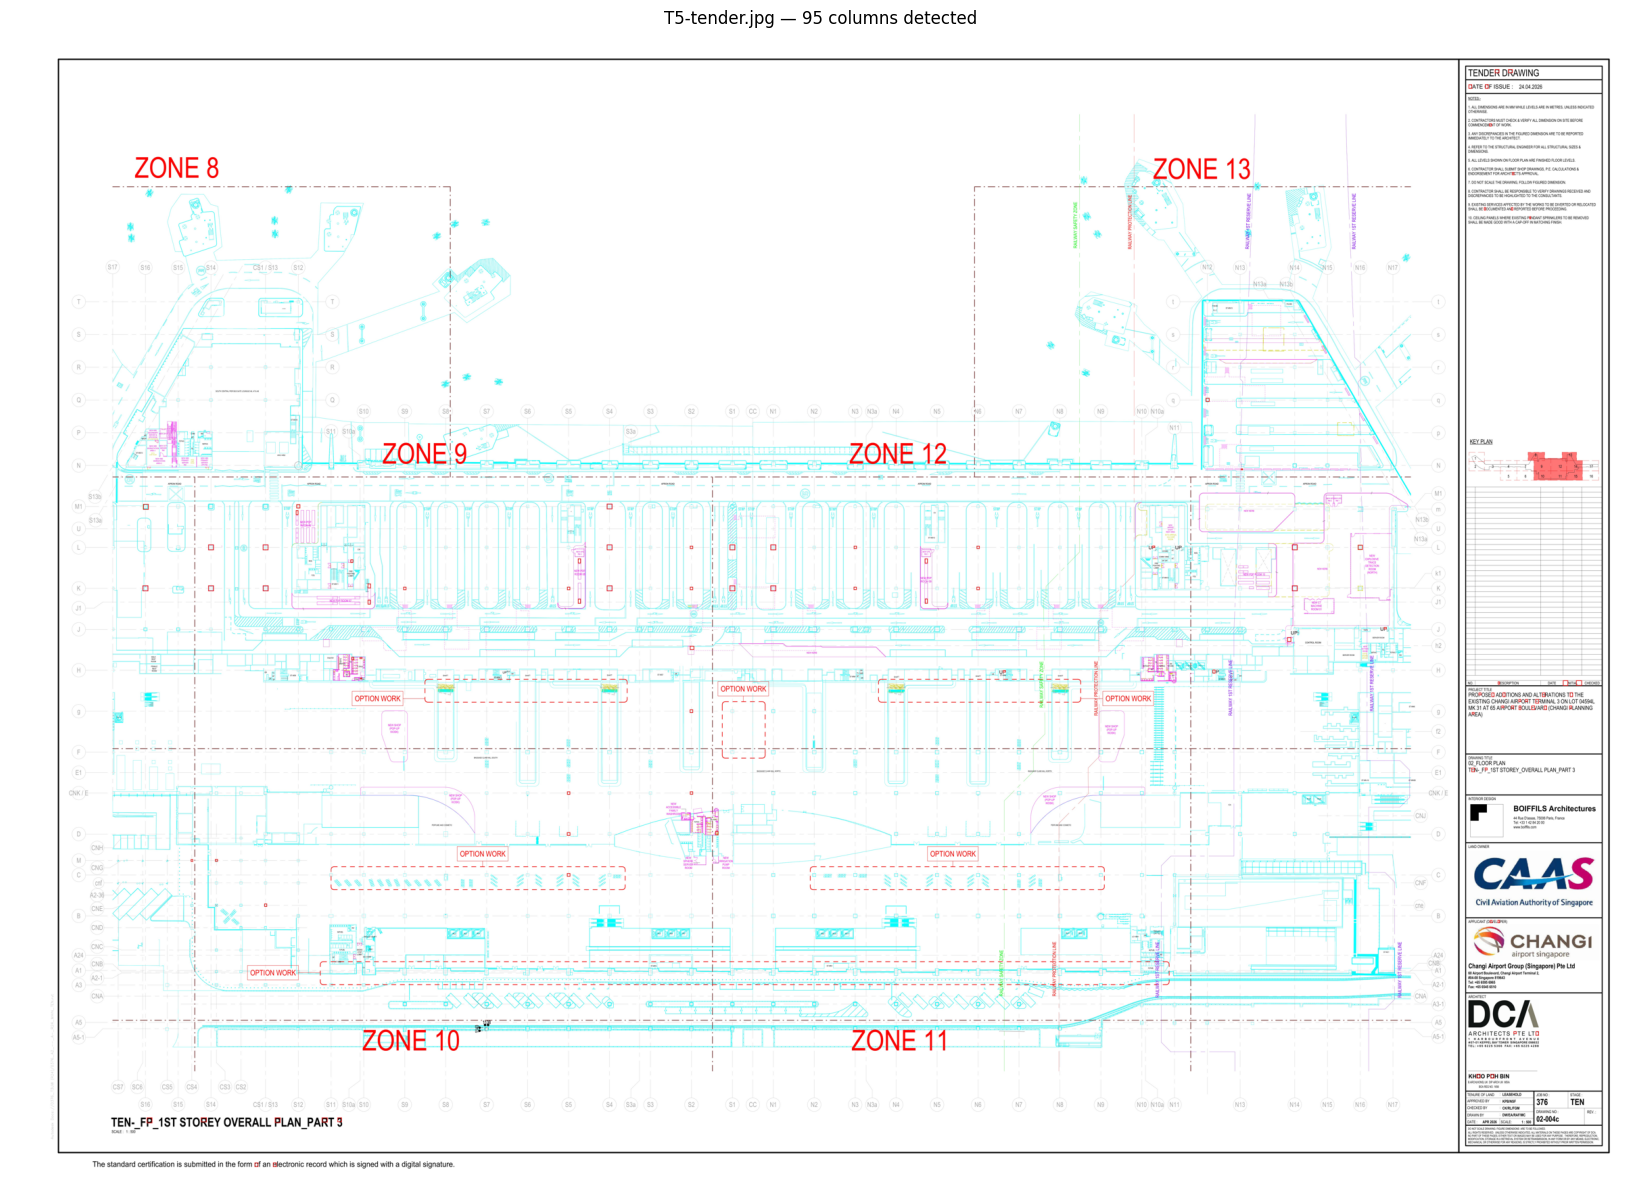

In [11]:
# ── PREVIEW (downscaled) ─────────────────────────────────────────────────
preview = annotated.copy()
preview.thumbnail((2400, 2400))
fig, ax = plt.subplots(figsize=(18, 12))
ax.imshow(preview)
ax.set_title(f'{IMAGE_PATH.name} — {len(boxes_final)} columns detected')
ax.axis('off')
plt.tight_layout()
plt.show()

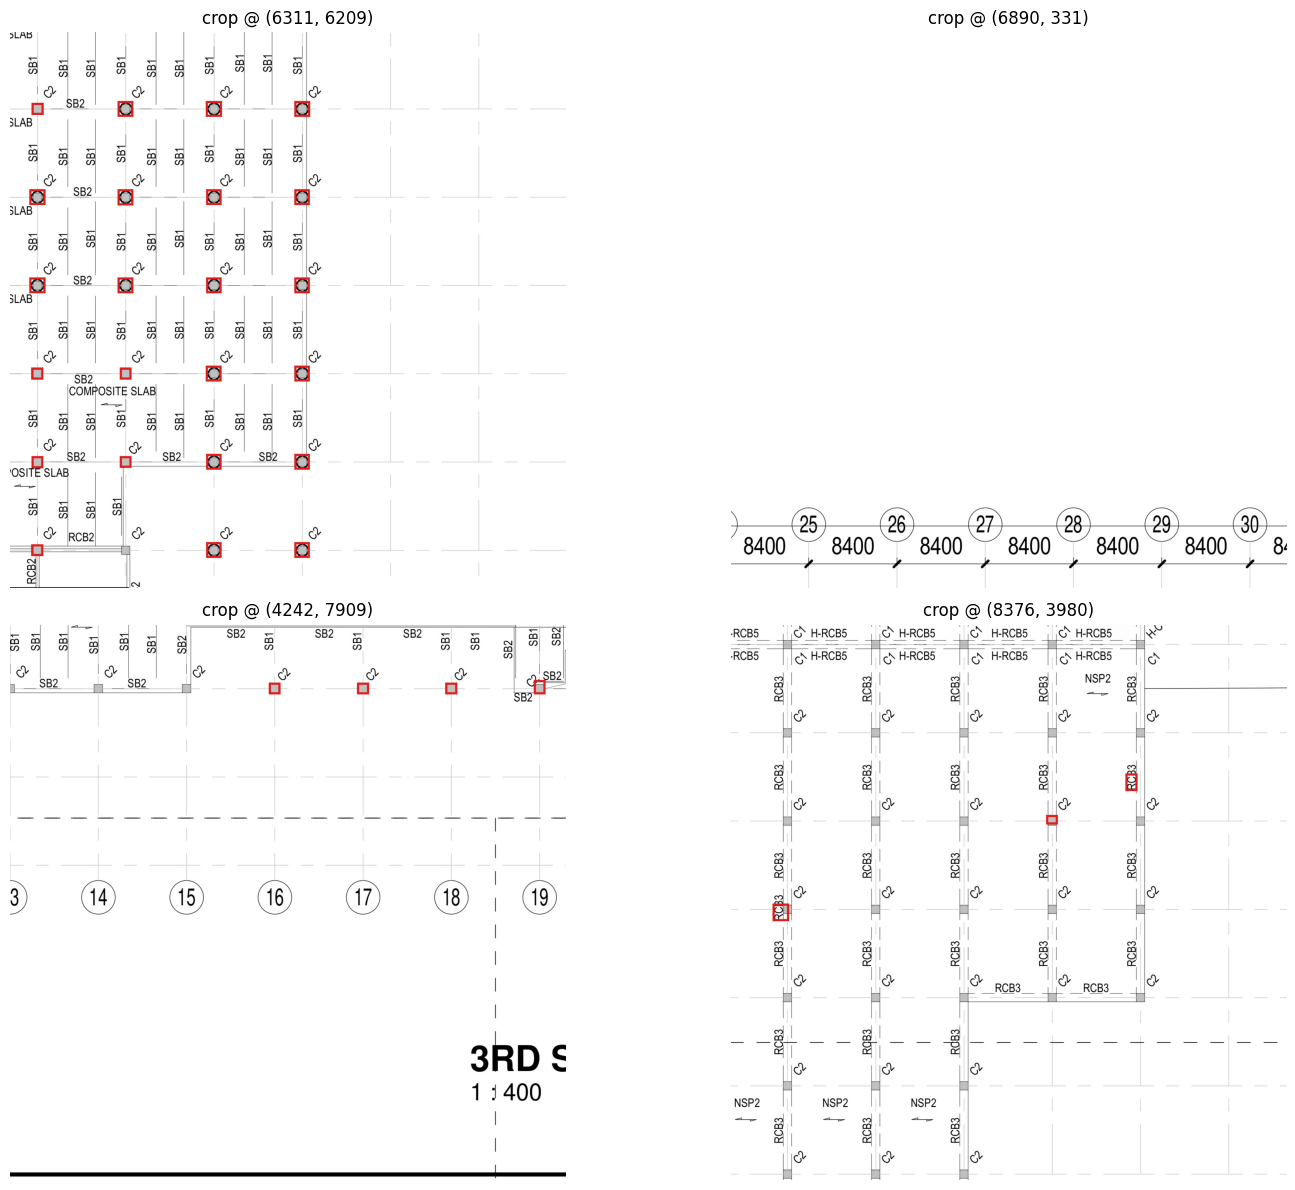

In [8]:
# ── ZOOM CROPS for visual QA ─────────────────────────────────────────────
# Pull 4 random 1500-px crops so you can eyeball detection quality at full res.
import random
random.seed(0)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
crop_size = 1500
for ax in axes.flatten():
    cx = random.randint(0, max(0, W - crop_size))
    cy = random.randint(0, max(0, H - crop_size))
    ax.imshow(annotated.crop((cx, cy, cx + crop_size, cy + crop_size)))
    ax.set_title(f'crop @ ({cx}, {cy})')
    ax.axis('off')
plt.tight_layout()
plt.show()

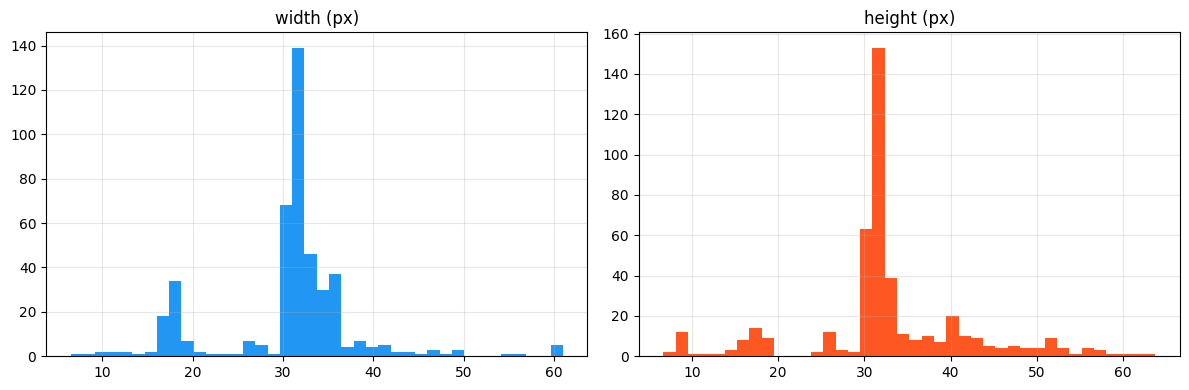

width  median 31.5 px (min 6, max 61)
height median 31.7 px (min 7, max 64)


In [10]:
# ── DETECTION SIZE HISTOGRAM ─────────────────────────────────────────────
# Lets you see whether round columns (24-42 px in tile space ≈ 24-42 px here)
# are picked up at the expected scale, separate from C2 squares (20-34 px).
widths  = boxes_final[:, 2] - boxes_final[:, 0]
heights = boxes_final[:, 3] - boxes_final[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=40, color='#2196F3'); axes[0].set_title('width (px)')
axes[1].hist(heights, bins=40, color='#FF5722'); axes[1].set_title('height (px)')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'width  median {np.median(widths):.1f} px (min {widths.min():.0f}, max {widths.max():.0f})')
print(f'height median {np.median(heights):.1f} px (min {heights.min():.0f}, max {heights.max():.0f})')